# 23. Evolving Images: Breeding as Composition

Every generator so far had dials you turned by hand. Today the dials become genes, turning them becomes mutation, and your only remaining instrument is choice: look at nine creatures, point at one, repeat. Composition by breeding.

## Today's destination

A specimen cabinet: four lineages, bred from one common ancestor (a near-featureless stick) in eight generations of mutation and choice, sampled every second generation. No shape in this cabinet was designed. Each is the accumulated record of one aesthetic preference applied repeatedly to random variation, which is to say: each one is a taste, made visible. The Latin names are invented, as in chapter 7's herbarium. By the end of today you will have bred creatures of your own, and met the reason this chapter refuses to automate you away.

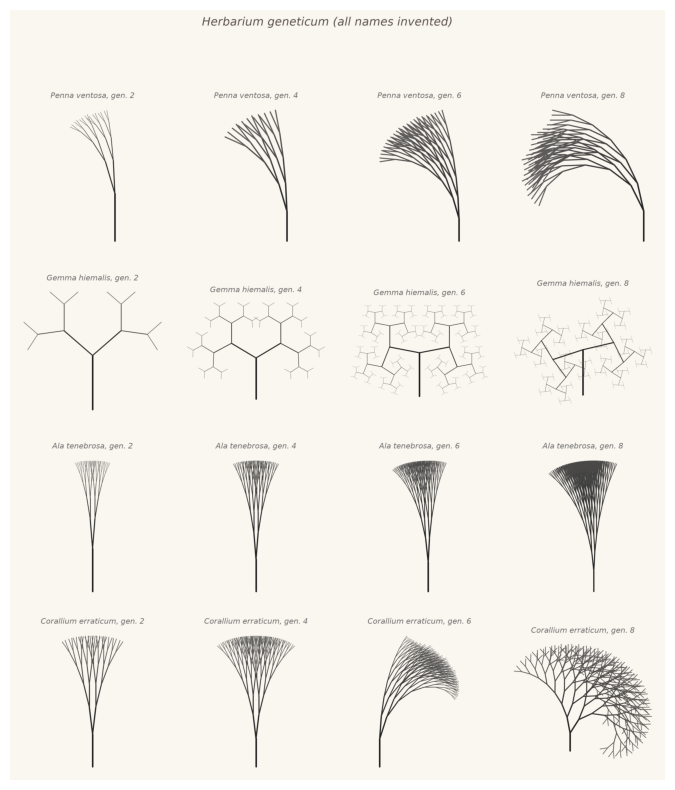

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch23_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: the artist as gardener

In chapter 3 of *The Blind Watchmaker* (1986), the biologist **Richard Dawkins** described a small program meant to demonstrate how evolution accumulates small changes. A branching creature he called a **biomorph** was specified by nine numeric genes; the screen showed a parent surrounded by a litter of mutant offspring, and the human picked the offspring that would parent the next litter. That was all: variation from the machine, selection from the eye. Dawkins expected tree-like shapes. What he got, within minutes of breeding, were insect-like creatures, and his account of the moment is one of the field's founding texts: "Nothing in my biologist's intuition, nothing in my 20 years' experience of programming computers, and nothing in my wildest dreams, prepared me for what actually emerged on the screen."

Artists were already nearby. **William Latham**, working with the mathematician **Stephen Todd** at the IBM UK Scientific Centre in Winchester, built the **Mutator** system (around 1989 to 1991) to breed his sculptural three-dimensional forms by aesthetic choice alone; their book *Evolutionary Art and Computers* (1992) documents both system and philosophy. Latham liked to describe his role as that of a **gardener**, tending and crossing forms he did not directly shape. **Karl Sims** then moved the selection itself into the museum: in *Genetic Images* (1993, shown at the Centre Georges Pompidou), sixteen screens displayed evolving abstract images and visitors voted with their feet, standing on sensors in front of the images they wanted to survive and breed; *Galápagos* (1997, NTT InterCommunication Center, Tokyo) did the same for animated virtual creatures on twelve screens. The audience became the selection pressure; the artwork was the population's drift through the audience's taste.

The idea underneath is older than computing. Darwin opened *On the Origin of Species* (1859) not with nature but with **pigeon breeders**: artificial selection, taste applied to variation over generations, was the mechanism his readers already believed in, and natural selection was introduced as its blind cousin. Evolutionary art runs the analogy in reverse, importing the breeder's power into image-making. One clause of honesty, though, before we romanticize the gardener: the artist who "only chooses" also designed the genome and the growth rules, so the choosing happens inside a space of forms the artist-programmer has already authored. Keep that clause; it is the difference between this chapter and a slot machine, and chapter 27 will ask you to defend it.

Today we build the whole apparatus in miniature: a genome, a growth program, a mutation operator, a litter, and you.

## Genotype and phenotype

Two words from biology earn their keep here. The **genotype** (Genotyp) is the compact description: for us, a plain dictionary of eight named numbers. The **phenotype** (Phänotyp) is the grown creature: the drawing the genes produce. Everything that happens today happens to the genotype; everything you *see* and judge is phenotype. The gap between the two, one number quietly reshaping an entire body, is where the surprises live.

Each gene lives inside fixed bounds, so mutation can never push a creature out of the printable world:

In [2]:
# the genome: eight named genes, each confined to sensible bounds
import numpy as np

GENOME_BOUNDS = {
    "angle": (0.08, 1.65),      # how wide the two branches open (radians)
    "asymmetry": (-0.9, 0.9),   # one side opens wider than the other
    "decay": (0.55, 0.94),      # how fast segments shorten with depth
    "depth": (3.0, 9.0),        # rounds of branching (rounded when growing)
    "length": (0.8, 1.8),       # trunk segment length
    "width": (0.5, 5.0),        # trunk line width
    "lean": (-0.6, 0.6),        # a bend added at every level: curl
    "shade": (0.0, 1.0),        # how quickly branches fade toward paper
}

ADAM = {"angle": 0.12, "asymmetry": 0.0, "decay": 0.7, "depth": 4.0,
        "length": 1.3, "width": 1.6, "lean": 0.0, "shade": 0.3}
for gene, value in ADAM.items():
    print(f"{gene:>10}: {value}")

     angle: 0.12
 asymmetry: 0.0
     decay: 0.7
     depth: 4.0
    length: 1.3
     width: 1.6
      lean: 0.0
     shade: 0.3


## The growth program

The phenotype grower is chapter 5's recursion wearing chapter 7's clothes: each call draws one segment, then calls itself twice, once per branch, with a shorter length and a turned heading. `sprout` computes the geometry (a list of segments, so later cells can *measure* creatures without drawing them), and `draw` renders it with depth-based width and fading, chapter 7's dressing rule.

In [3]:
# sprout: the recursive growth program (geometry only, no drawing)
def sprout(genome, x=0.0, y=0.0, heading=np.pi / 2, level=0, segments=None):
    if segments is None:
        segments = []
    if level == round(genome["depth"]):        # base case: deep enough, stop
        return segments
    length = genome["length"] * genome["decay"]**level
    nx = x + length * np.cos(heading)
    ny = y + length * np.sin(heading)
    segments.append((x, y, nx, ny, level))
    open_left = genome["angle"] * (1 + genome["asymmetry"])
    open_right = genome["angle"] * (1 - genome["asymmetry"])
    sprout(genome, nx, ny, heading + open_left + genome["lean"], level + 1, segments)
    sprout(genome, nx, ny, heading - open_right + genome["lean"], level + 1, segments)
    return segments

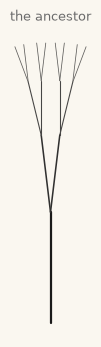

In [4]:
# draw: render a genome's phenotype onto an axis, ink on paper
from matplotlib.colors import to_rgb
import sys
sys.path.append("..")
from agap.helpers import save_artwork, PAPER

def draw(ax, genome, ink="#1A1A1A"):
    ink_rgb = np.array(to_rgb(ink))
    paper_rgb = np.array(to_rgb(PAPER))
    depth = round(genome["depth"])
    for x0, y0, x1, y1, level in sprout(genome):
        fade = genome["shade"] * level / max(depth - 1, 1)
        color = ink_rgb * (1 - fade) + paper_rgb * fade    # blend toward paper
        ax.plot([x0, x1], [y0, y1], color=color, solid_capstyle="round",
                lw=genome["width"] * genome["decay"]**level)
    ax.set_facecolor(PAPER)
    ax.set_aspect("equal")
    ax.axis("off")

fig, ax = plt.subplots(figsize=(4, 4), facecolor=PAPER)
draw(ax, ADAM)
ax.set_title("the ancestor", fontsize=9, color="#6B6B6B")
plt.show()

A modest broom. Every creature in this chapter, including the whole showpiece cabinet, descends from this one genome; hold on to how little it promises.

## Mutation and the litter

A **mutation** (Mutation) picks *one* gene at random and nudges it by a Gaussian amount, chapter 2's `rng.normal` scaled to about a fifth of the gene's range, then clamps to the bounds:

$$g' = \mathrm{clip}\big(g + \mathcal{N}(0,\; \sigma^2) ,\; \mathrm{lo},\; \mathrm{hi}\big), \qquad \sigma = 0.22 \cdot \mathrm{range},$$

A **litter** is nine copies of the parent: eight mutants around one unchanged original (slot 4, the middle of the 3 by 3 grid), Dawkins' interface exactly. Seeding matters here more than anywhere in the book, and the discipline is chapter 2's contract paying off: every litter is grown from `base_seed + generation`, so a whole lineage is reproducible from just two things, the base seed and the list of your choices.

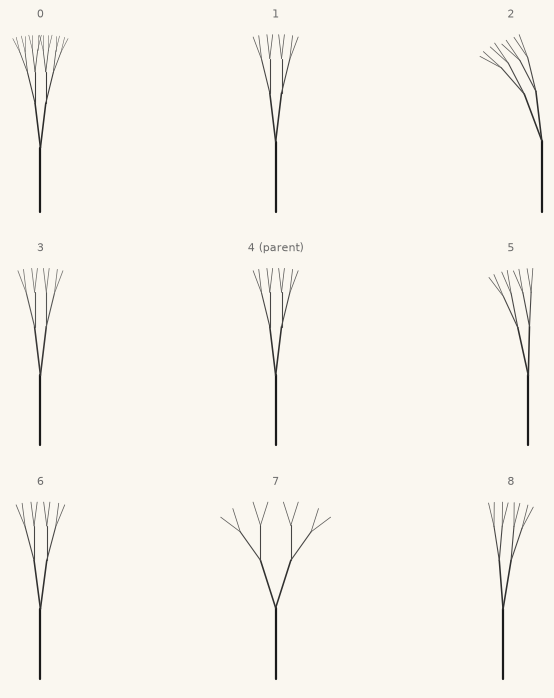

In [5]:
# mutate one gene; grow a litter of nine; replay a recorded lineage
def mutate(genome, rng):
    child = dict(genome)                       # copy: the parent is never edited
    gene = rng.choice(list(GENOME_BOUNDS))
    lo, hi = GENOME_BOUNDS[gene]
    child[gene] = float(np.clip(child[gene] + rng.normal(0, 0.22 * (hi - lo)),
                                lo, hi))
    return child

def litter(parent, seed):
    rng = np.random.default_rng(seed)
    kids = [mutate(parent, rng) for _ in range(9)]
    kids[4] = dict(parent)                     # the parent sits in the middle
    return kids

def replay(choices, base_seed):
    parent = dict(ADAM)
    for generation, pick in enumerate(choices):
        parent = litter(parent, seed=base_seed + generation)[pick]
    return parent

def show_litter(parent, seed):
    kids = litter(parent, seed)
    fig, axes = plt.subplots(3, 3, figsize=(8.6, 8.6), facecolor=PAPER)
    for k, (ax, kid) in enumerate(zip(axes.flat, kids)):
        draw(ax, kid)
        label = "4 (parent)" if k == 4 else str(k)
        ax.set_title(label, fontsize=8, color="#6B6B6B")
    plt.show()

show_litter(ADAM, seed=1)      # the ancestor's first litter: eight nudges

## The breeding pen

Here is the whole apparatus in one cell. Your lineage is the list `my_choices`: look at the litter below, decide which creature deserves children, **append its number to the list, and run the cell again**. The litter of your chosen one appears; repeat. No widgets, no sliders: the artwork is a growing list of small decisions, and because of the seed chain, that list *is* the artwork's complete recipe (write it down and any reader of this book can regrow your creature).

**Try it now**, before reading further: five or six generations, following any whim, noticing what you find yourself selecting *for*.

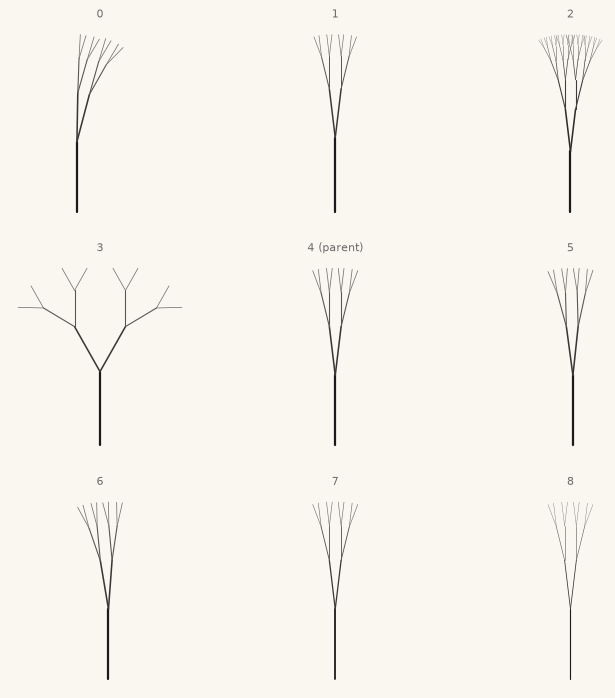

In [6]:
# the breeding pen: append your pick to the list, run again, repeat
my_choices = [3]                     # your lineage so far; start is one pick
my_parent = replay(my_choices, base_seed=1)
show_litter(my_parent, seed=1 + len(my_choices))

## A scripted lineage

To show what patient selection can do, here is a recorded lineage: eight generations, base seed 5, choices fixed. Watching it unfold is watching a preference (in this case: *curl, and keep the fine detail*) compound generation by generation, from the stick to something that would not embarrass a reef.

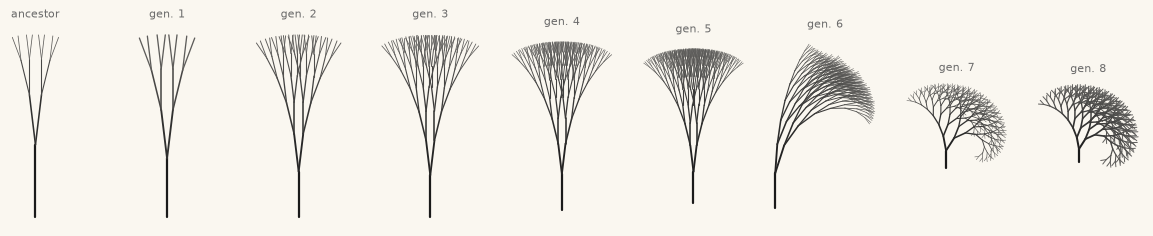

In [7]:
# eight generations of one recorded taste: stick to coral
coral_choices = [8, 0, 7, 5, 7, 0, 5, 1]
fig, axes = plt.subplots(1, 9, figsize=(15, 2.6), facecolor=PAPER)
draw(axes[0], ADAM)
axes[0].set_title("ancestor", fontsize=8, color="#6B6B6B")
for generation in range(8):
    stage = replay(coral_choices[:generation + 1], base_seed=5)
    draw(axes[generation + 1], stage)
    axes[generation + 1].set_title(f"gen. {generation + 1}", fontsize=8,
                                   color="#6B6B6B")
plt.show()

Notice what the picture sequence hides: at every one of those eight steps there were *eight roads not taken*, and the recorded creature is one path through a tree of $9^8$, about forty-three million, possible descendants. Breeding does not design a form; it steers through a space of forms too large to see. (Chapter 27 will give this a name: exploratory creativity, from the philosopher Margaret Boden.)

## The machine that wanted symmetry

The obvious next thought, for anyone who has met chapter 21's optimizing slime mold, is: why keep the human at all? Write down what makes a creature *good*, let the computer breed toward it, go for coffee. Let us try, in the most careful way we can. We will ask for **bilateral symmetry**, a property with a genuinely computable definition: grow the creature, rasterize its segment endpoints into a coarse grid (`np.histogram2d`, chapter 9's census of visits, here on a 32 by 32 grid), mirror the grid, and score how well the two agree, 1.0 meaning perfect. Then hill-climb: mutate, keep the child only if the score rises, two hundred times.

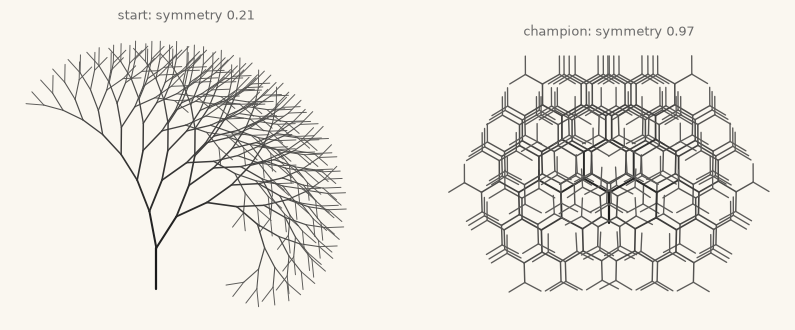

In [8]:
# formal fitness: bilateral symmetry of the rasterized creature, 0..1
def symmetry_score(genome):
    seg = np.array(sprout(genome))
    xs = np.concatenate([seg[:, 0], seg[:, 2]])    # all endpoints, both ends
    ys = np.concatenate([seg[:, 1], seg[:, 3]])
    span = max(np.abs(xs).max(), 1e-6)
    counts, _, _ = np.histogram2d(xs, ys, bins=32,
                                  range=[[-span, span], [ys.min(), ys.max() + 1e-6]])
    overlap_error = np.abs(counts - counts[::-1, :]).sum()   # vs the mirror image
    return 1 - overlap_error / max(counts.sum() * 2, 1e-6)

# hill-climb: mutate, keep only improvements, 200 attempts
start = replay(coral_choices, base_seed=5)         # the coral, our best creature
rng = np.random.default_rng(18)
champion, best = dict(start), symmetry_score(start)
for attempt in range(200):
    contender = mutate(champion, rng)
    score = symmetry_score(contender)
    if score > best:
        champion, best = contender, score

fig, axes = plt.subplots(1, 2, figsize=(10, 5.4), facecolor=PAPER)
draw(axes[0], start)
axes[0].set_title(f"start: symmetry {symmetry_score(start):.2f}", fontsize=9,
                  color="#6B6B6B")
draw(axes[1], champion)
axes[1].set_title(f"champion: symmetry {best:.2f}", fontsize=9, color="#6B6B6B")
plt.show()

The machine did exactly what we asked. It took our curling coral and bred it, in two hundred patient steps, into a lattice of overlapping hexagons: symmetry 0.97, nearly perfect, and achieved by a trick no breeder-by-eye would ever have reached for, making the form so dense and regular that it coincides with its own mirror image. It is a remarkable object. It is also *not what we meant*, and no adjustment of the number would have said what we meant, because what we meant was not symmetry, it was something like "the coral, but composed", a criterion we can recognize in one glance and cannot write down.

This failure is famous enough to have a shape: an optimizer given a proxy for what you want will optimize the proxy, and the gap between proxy and want is where the strangeness pours in. The pioneers all reached the same conclusion from the same experience. Sims put museum visitors on pressure sensors rather than trusting a formula; Latham stayed in the loop as gardener; and decades of research on computable aesthetics (it is a real field, with surveys) have not yet produced a fitness function anyone would let breed unsupervised. Taste, whatever it is, currently compresses worse than form does. Your eye stays employed.

**Try it.** Write a different wish into `symmetry_score` (tallest is a one-line body: `return np.array(sprout(genome))[:, 3].max()`; bushiest? most ground covered?) and run the climb again; watch how literal-mindedly the machine grants it. This is exercise (c) in embryo.

## Four lineages

The showpiece cabinet at the top of this notebook breeds four different tastes from the same ancestor, sampled at generations 2, 4, 6 and 8, one lineage per row. Their invented Latin labels follow chapter 7's herbarium convention (the names are fiction; the specimens are honest):

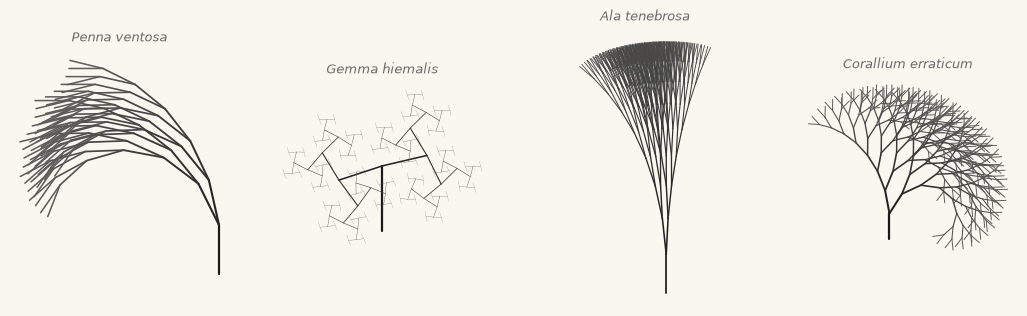

In [9]:
# the four recorded lineages of the cabinet: base seed, choices, invented name
LINEAGES = [
    ("Penna ventosa", 18, [1, 5, 1, 0, 2, 8, 8, 0]),
    ("Gemma hiemalis", 92, [7, 7, 0, 3, 3, 5, 2, 6]),
    ("Ala tenebrosa", 77, [0, 5, 2, 0, 2, 5, 3, 0]),
    ("Corallium erraticum", 5, [8, 0, 7, 5, 7, 0, 5, 1]),
]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), facecolor=PAPER)
for ax, (latin, base, choices) in zip(axes, LINEAGES):
    draw(ax, replay(choices, base_seed=base))
    ax.set_title(latin, fontsize=9, color="#6B6B6B", fontstyle="italic")
plt.show()

**Look and compare.** Four temperaments from one stick: a grass in the wind, a winter crystal, a folded wing, a curl of reef. All eight genes are identical in kind across the four; only the *history of choices* differs. Can you tell, looking at a finished creature, what its breeder was selecting for? (Try to name each lineage's taste in one word before reading its Latin name again; the names contain our answers.)

## Export your artwork

Breed something in the pen above (or perturb a recorded lineage: change one number in its choices and watch history fork), then render your champion large and sign it with its recipe. Replace `yourname` and run.

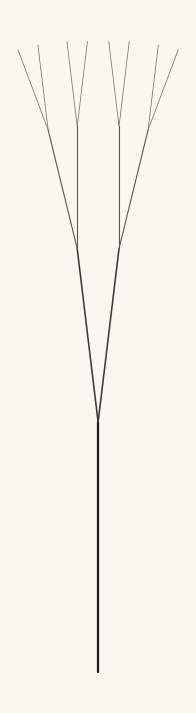

saved: assets/outputs/ch23_yourname.png
recipe: base_seed=1, choices = [3]


In [10]:
# save YOUR artwork: your champion, grown large; replace 'yourname'
my_champion = replay(my_choices, base_seed=1)      # or any (choices, base) pair
fig, ax = plt.subplots(figsize=(9, 9), facecolor=PAPER)
draw(ax, my_champion)
plt.show()
saved_path = save_artwork(fig, "yourname", chapter=23)
print("recipe: base_seed=1, choices =", my_choices)

## Exercises

**(a) Parameter exploration: breed for a brief.** Ten generations in the breeding pen, but with a commission: *most insect-like*. (Dawkins' original astonishment was exactly this: insects from a program written to draw trees.) Save your lineage strip and its recipe, and note the generation at which "insect" stopped being your projection and started being a defensible description.

**(b) Code modification: a ninth gene.** Add `branches` to the genome: 2 or 3 children per node, bounds `(2.0, 3.0)`, rounded at use like `depth`. Thread it through all three places a gene must live: the bounds (so `mutate` can find it), the ancestor (so every creature carries it), and `sprout` (so it changes the body). Three-branched litters get bushy fast; breed one for a few generations.

<details><summary>Solution</summary>

```python
GENOME_BOUNDS["branches"] = (2.0, 3.0)
ADAM["branches"] = 2.0

def sprout(genome, x=0.0, y=0.0, heading=np.pi / 2, level=0, segments=None):
    if segments is None:
        segments = []
    if level == round(genome["depth"]):
        return segments
    length = genome["length"] * genome["decay"]**level
    nx = x + length * np.cos(heading)
    ny = y + length * np.sin(heading)
    segments.append((x, y, nx, ny, level))
    open_left = genome["angle"] * (1 + genome["asymmetry"])
    open_right = genome["angle"] * (1 - genome["asymmetry"])
    count = round(genome["branches"])
    for i in range(count):
        share = i / (count - 1)                # 0 to 1 across the fan
        turn = open_left - share * (open_left + open_right)
        sprout(genome, nx, ny, heading + turn + genome["lean"], level + 1,
               segments)
    return segments

eve = dict(ADAM, branches=3.0, depth=6.0, angle=0.5)
show_litter(eve, seed=7)
```

Redefining `sprout` replaces the two-branch original (re-run the definition cell above to get it back). The `share` line spreads any number of children evenly across the fan between the old left and right branches, so `branches=2.0` still reproduces the original creatures exactly: a new gene should be *backwards compatible* with the ancestors, or every recorded lineage in the chapter breaks. Old genomes lack the key, hence `genome["branches"]` would fail on them; that is why `eve` is built with `dict(ADAM, branches=...)` and why the bounds and ancestor must be updated together. One warning before you regrow anything recorded: with nine keys in the bounds, `rng.choice` deals the genes differently, so every recorded lineage in this chapter regrows into different creatures until you restart and run from the top.
</details>

**(c) Creative challenge: your own formal fitness.** Invent a computable wish (darkest? widest? most fern-like, by comparing against a rasterized chapter 7 fern?), hill-climb it, and critique the winner in three written sentences: what did you ask for, what did you get, and where exactly did the two diverge? Keep the three sentences; they are a rehearsal for the authorship discussion in chapter 27, and for the statement your final project must include.

## Further reading

- Richard Dawkins, *The Blind Watchmaker* (1986), chapter 3: the biomorphs, in the author's own astonished voice.
- Stephen Todd and William Latham, *Evolutionary Art and Computers* (Academic Press, 1992): the Mutator system and the gardener's philosophy, from inside the IBM lab.
- Karl Sims, karlsims.com (free): the artist's own pages on *Genetic Images* and *Galápagos*, with photographs of the installations.
- Mitchell Whitelaw, *Metacreation: Art and Artificial Life* (MIT Press, 2004), especially the "Breeders" chapter: the art-historical account of Sims, Latham and their kin.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the specimen cabinet shown at the top of the notebook: the four recorded lineages, one per row, sampled at generations 2, 4, 6 and 8. Ink on paper, invented Latin, honest genes. It runs automatically with *Restart & Run All*.

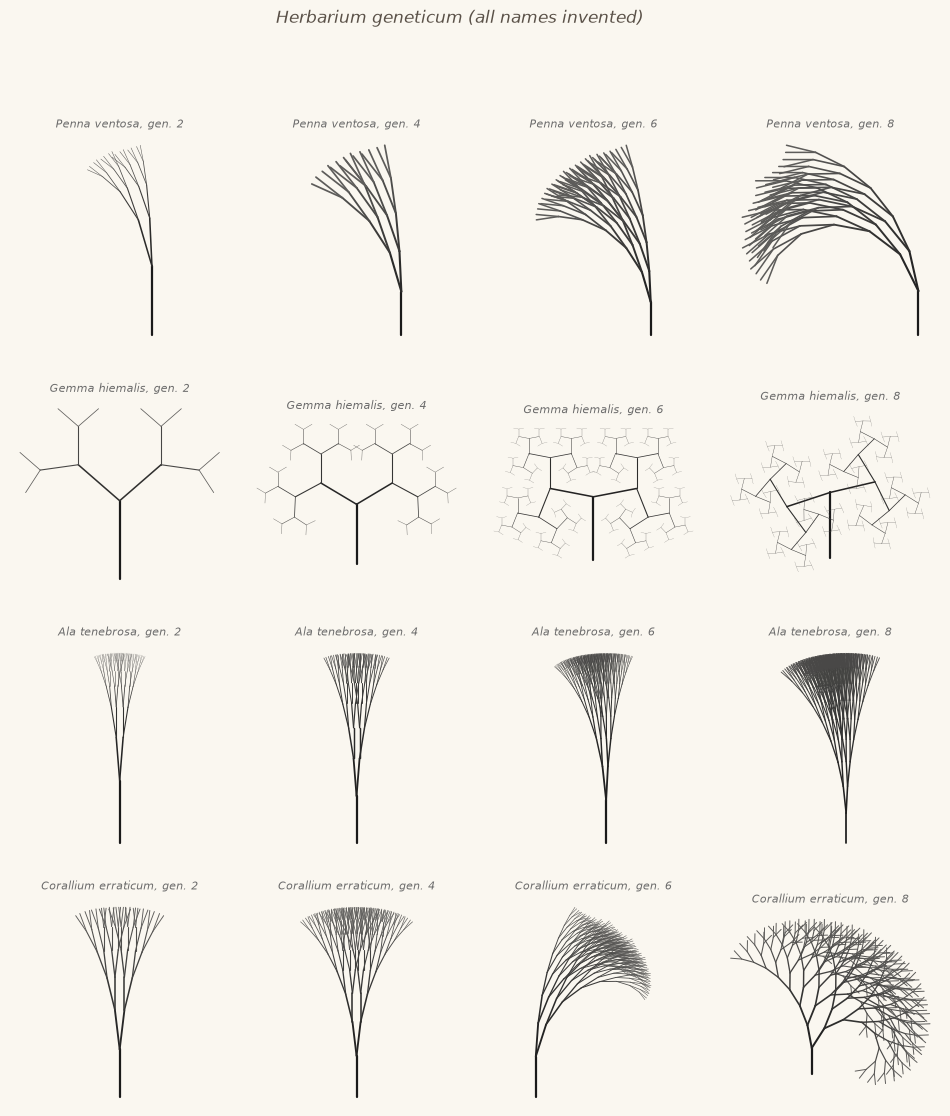

saved: assets/outputs/ch23_showpiece.png


In [11]:
# regenerate this chapter's showpiece: the specimen cabinet, 4 lineages x 4 stages
fig, axes = plt.subplots(4, 4, figsize=(12, 12.6), facecolor=PAPER)
for row, (latin, base, choices) in enumerate(LINEAGES):
    for col, generation in enumerate([2, 4, 6, 8]):
        ax = axes[row, col]
        draw(ax, replay(choices[:generation], base_seed=base))
        ax.set_title(f"{latin}, gen. {generation}", fontsize=8,
                     color="#6B6B6B", fontstyle="italic")
fig.suptitle("Herbarium geneticum (all names invented)", fontsize=12,
             color="#5A5148", fontstyle="italic")
fig.subplots_adjust(wspace=0.08, hspace=0.22)
plt.show()
saved_path = save_artwork(fig, "showpiece", chapter=23)